<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW1/HW1_CIFAR10_CNN_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW1

https://github.com/JordanTerwilliger/Intro-to-Deep-Learning

### ResNet-18 Implementation for CIFAR-10
This notebook implements a ResNet-18 architecture from scratch using PyTorch, specifically optimized for the CIFAR-10 dataset.

#No Dropout

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision

import torchvision.transforms as transforms

import time

from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from torchsummary import summary

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

torch.manual_seed(1)

# Global list to store metrics for all models
all_model_results = []

epochs = 30 #Should be 50 but training time sucks
learning_rate = 0.01

Using device: cpu


In [2]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64
        # Modified for CIFAR-10: 3x3 conv instead of 7x7, no maxpool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet11():
    return ResNet(BasicBlock, [1, 1, 1, 1])

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle = True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle = False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:08<00:00, 19.2MB/s]


In [5]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # CIFAR-10 image classes

##ResNet-11

In [8]:
net = ResNet11().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [9]:
net.to(device)
print(summary(net, input_size=(3,32,32)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-13          [-1, 128, 16, 16]          73,728
      BatchNorm2d-14          [-1, 128,

Begin Training

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-11 Baseline", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

Epoch: 0, Loss: 1.5324, Accuracy: 57.71%
Epoch: 1, Loss: 1.0136, Accuracy: 66.67%
Epoch: 2, Loss: 0.7637, Accuracy: 73.03%
Epoch: 3, Loss: 0.6003, Accuracy: 75.84%
Epoch: 4, Loss: 0.4976, Accuracy: 74.58%
Epoch: 5, Loss: 0.3749, Accuracy: 77.45%
Epoch: 6, Loss: 0.3468, Accuracy: 73.34%
Epoch: 7, Loss: 0.2789, Accuracy: 76.53%
Epoch: 8, Loss: 0.2535, Accuracy: 77.02%
Epoch: 9, Loss: 0.2257, Accuracy: 77.53%
Epoch: 10, Loss: 0.1939, Accuracy: 79.63%
Epoch: 11, Loss: 0.1603, Accuracy: 81.39%
Epoch: 12, Loss: 0.1368, Accuracy: 83.37%
Epoch: 13, Loss: 0.1318, Accuracy: 83.39%
Epoch: 14, Loss: 0.1304, Accuracy: 83.39%
Epoch: 15, Loss: 0.1281, Accuracy: 83.48%
Epoch: 16, Loss: 0.1267, Accuracy: 83.55%
Epoch: 17, Loss: 0.1257, Accuracy: 83.53%
Epoch: 18, Loss: 0.1250, Accuracy: 83.58%
Epoch: 19, Loss: 0.1243, Accuracy: 83.52%
Epoch: 20, Loss: 0.1233, Accuracy: 83.58%
Epoch: 21, Loss: 0.1222, Accuracy: 83.49%
Epoch: 22, Loss: 0.1214, Accuracy: 83.50%
Epoch: 23, Loss: 0.1205, Accuracy: 83.55%
Ep

In [ ]:
# Export the model weights
model_name = "ResNet11_Baseline"
# Fixed: Changed state_dictionary() to state_dict()
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Model saved as ResNet11_Baseline.pth


### 1. Training and Validation Curves
Visualization of the loss and accuracy over epochs.

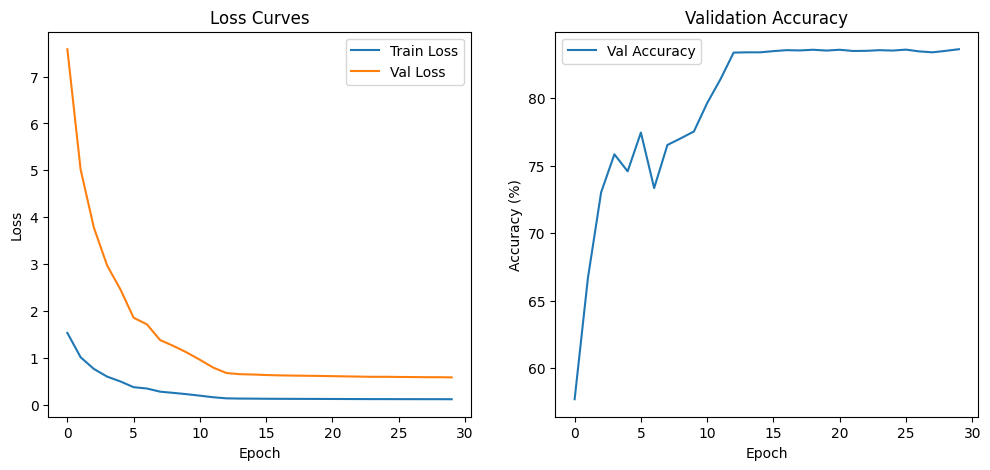

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

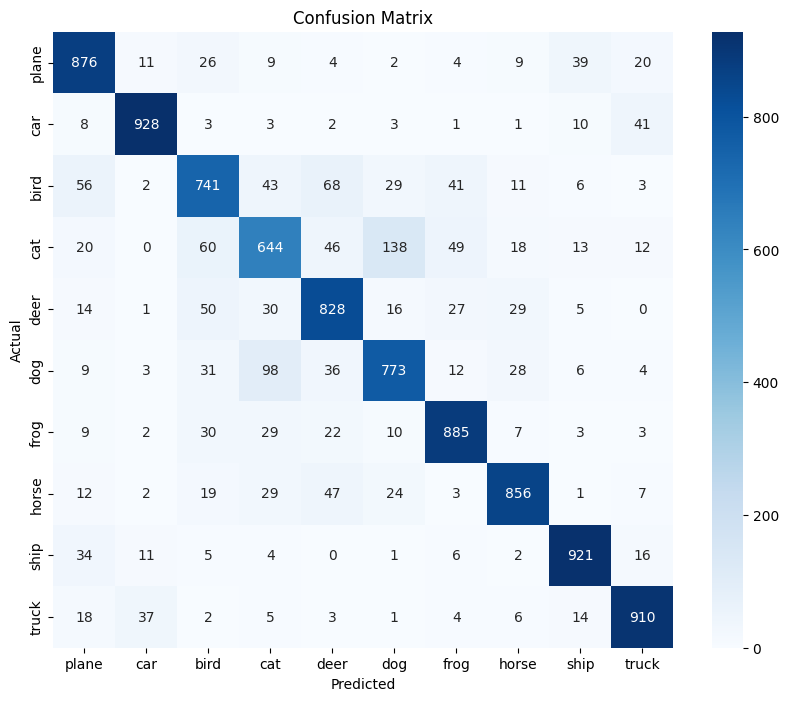

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##ResNet-18

In [ ]:
net = ResNet18().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-18 Baseline", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

# Export the model weights
model_name = "ResNet18_Baseline"
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Epoch: 0, Loss: 1.5425, Accuracy: 57.49%
Epoch: 1, Loss: 0.9235, Accuracy: 70.66%
Epoch: 2, Loss: 0.6823, Accuracy: 73.85%
Epoch: 3, Loss: 0.5140, Accuracy: 77.45%
Epoch: 4, Loss: 0.4033, Accuracy: 77.70%
Epoch: 5, Loss: 0.3303, Accuracy: 78.82%
Epoch: 6, Loss: 0.2798, Accuracy: 78.55%
Epoch: 7, Loss: 0.2588, Accuracy: 79.42%
Epoch: 8, Loss: 0.2478, Accuracy: 76.98%
Epoch: 9, Loss: 0.2238, Accuracy: 80.03%
Epoch: 10, Loss: 0.2109, Accuracy: 80.80%
Epoch: 11, Loss: 0.1783, Accuracy: 81.59%
Epoch: 12, Loss: 0.1705, Accuracy: 82.25%
Epoch: 13, Loss: 0.1525, Accuracy: 83.25%
Epoch: 14, Loss: 0.1339, Accuracy: 84.57%
Epoch: 15, Loss: 0.1295, Accuracy: 84.62%
Epoch: 16, Loss: 0.1263, Accuracy: 84.69%
Epoch: 17, Loss: 0.1240, Accuracy: 84.82%
Epoch: 18, Loss: 0.1213, Accuracy: 84.98%
Epoch: 19, Loss: 0.1191, Accuracy: 85.00%
Epoch: 20, Loss: 0.1176, Accuracy: 85.01%
Epoch: 21, Loss: 0.1163, Accuracy: 84.93%
Epoch: 22, Loss: 0.1147, Accuracy: 85.02%
Epoch: 23, Loss: 0.1138, Accuracy: 85.07%
Ep

### 1. Training and Validation Curves
Visualization of the loss and accuracy over epochs.

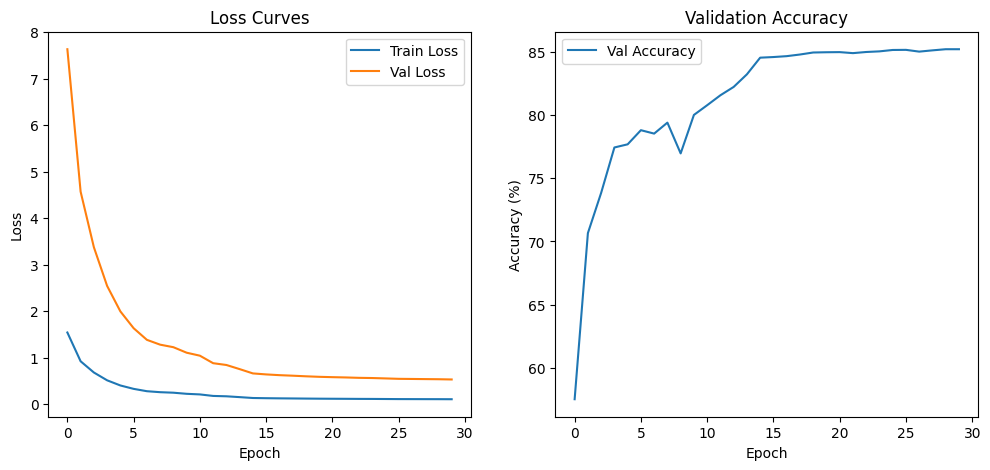

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

### 2. Confusion Matrix
Detailed performance across all 10 CIFAR-10 classes.

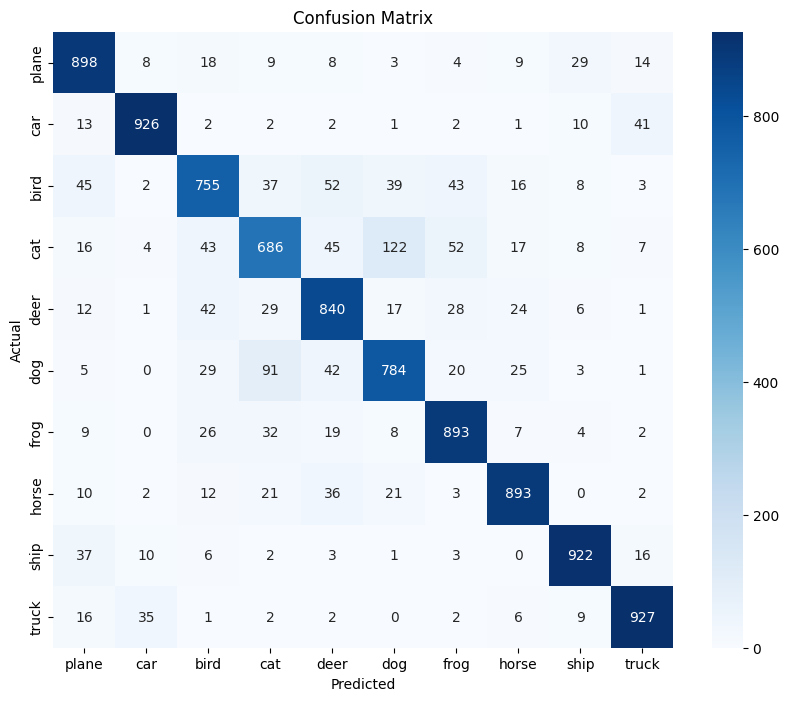

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 3. Final Summary
Comparison metrics for the report.

#Dropout p=0.3

In [ ]:
class ResNetWithDropout(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_p=0.0):
        super(ResNetWithDropout, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Dropout applied after Global Average Pooling
        self.dropout = nn.Dropout(p=dropout_p)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.linear(out)
        return out

def ResNet11_Dropout(p=0.3):
    return ResNetWithDropout(BasicBlock, [1, 1, 1, 1], dropout_p=p)

def ResNet18_Dropout(p=0.3):
    return ResNetWithDropout(BasicBlock, [2, 2, 2, 2], dropout_p=p)

##Resnet-11

In [ ]:
net = ResNet11_Dropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-11 (p=0.3)", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

# Export the model weights
model_name = "ResNet11_Dropout_03"
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Epoch: 0, Loss: 1.5609, Accuracy: 61.11%
Epoch: 1, Loss: 1.0643, Accuracy: 70.45%
Epoch: 2, Loss: 0.8539, Accuracy: 69.89%
Epoch: 3, Loss: 0.6742, Accuracy: 76.77%
Epoch: 4, Loss: 0.5490, Accuracy: 78.89%
Epoch: 5, Loss: 0.5061, Accuracy: 73.63%
Epoch: 6, Loss: 0.3881, Accuracy: 77.53%
Epoch: 7, Loss: 0.3319, Accuracy: 77.64%
Epoch: 8, Loss: 0.2959, Accuracy: 77.47%
Epoch: 9, Loss: 0.2595, Accuracy: 78.08%
Epoch: 10, Loss: 0.2449, Accuracy: 78.06%
Epoch: 11, Loss: 0.2497, Accuracy: 77.20%
Epoch: 12, Loss: 0.2205, Accuracy: 79.08%
Epoch: 13, Loss: 0.2112, Accuracy: 79.51%
Epoch: 14, Loss: 0.2013, Accuracy: 81.31%
Epoch: 15, Loss: 0.1714, Accuracy: 81.17%
Epoch: 16, Loss: 0.1592, Accuracy: 82.05%
Epoch: 17, Loss: 0.1395, Accuracy: 83.64%
Epoch: 18, Loss: 0.1315, Accuracy: 83.90%
Epoch: 19, Loss: 0.1291, Accuracy: 84.04%
Epoch: 20, Loss: 0.1259, Accuracy: 84.27%
Epoch: 21, Loss: 0.1236, Accuracy: 84.12%
Epoch: 22, Loss: 0.1220, Accuracy: 84.24%
Epoch: 23, Loss: 0.1204, Accuracy: 84.17%
Ep

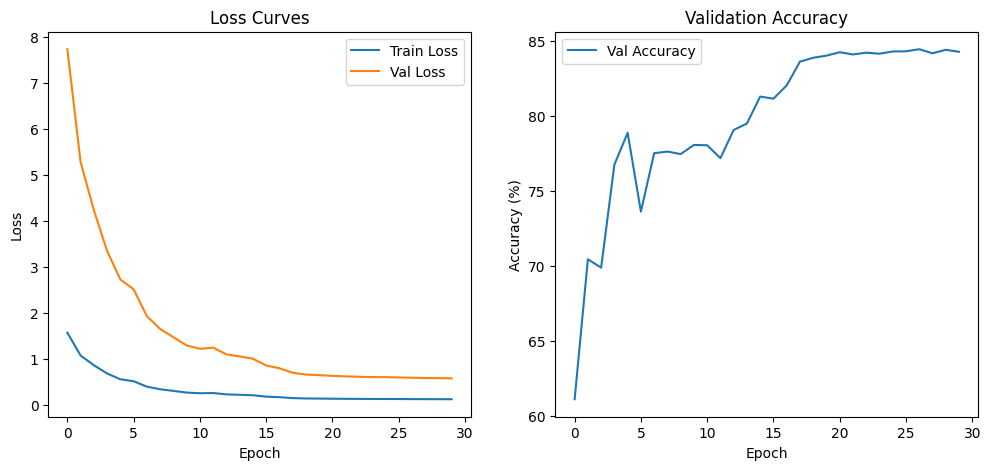

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

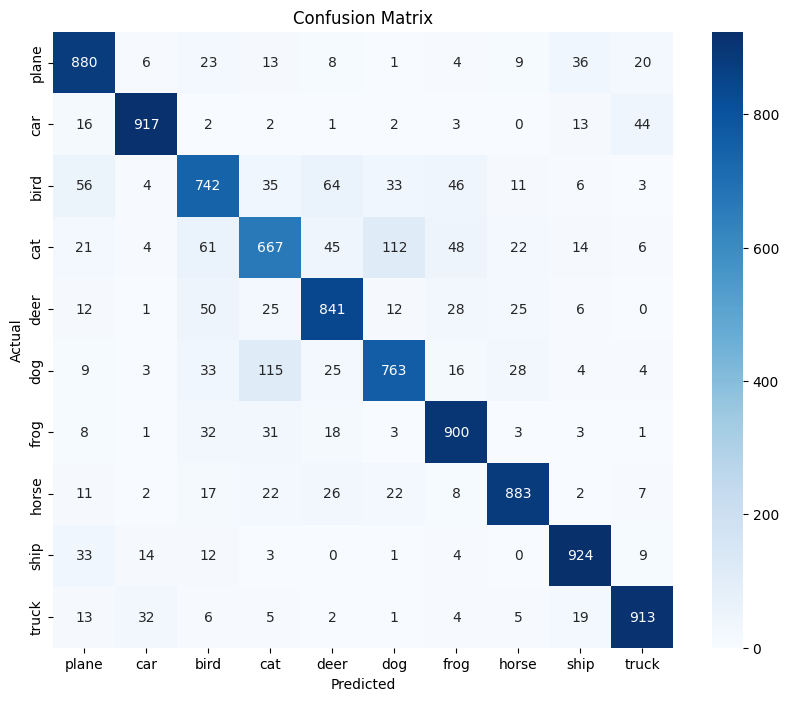

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##Resnet-18

In [ ]:
net = ResNet18_Dropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-18 (p=0.3)", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

# Export the model weights
model_name = "ResNet18_Dropout_03"
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Epoch: 0, Loss: 1.5775, Accuracy: 62.26%
Epoch: 1, Loss: 1.0099, Accuracy: 70.41%
Epoch: 2, Loss: 0.7309, Accuracy: 75.77%
Epoch: 3, Loss: 0.5522, Accuracy: 80.80%
Epoch: 4, Loss: 0.4326, Accuracy: 80.78%
Epoch: 5, Loss: 0.3806, Accuracy: 77.77%
Epoch: 6, Loss: 0.3313, Accuracy: 79.04%
Epoch: 7, Loss: 0.2773, Accuracy: 79.98%
Epoch: 8, Loss: 0.2723, Accuracy: 77.36%
Epoch: 9, Loss: 0.2112, Accuracy: 81.83%
Epoch: 10, Loss: 0.2297, Accuracy: 80.08%
Epoch: 11, Loss: 0.2603, Accuracy: 78.01%
Epoch: 12, Loss: 0.2217, Accuracy: 80.16%
Epoch: 13, Loss: 0.1721, Accuracy: 82.97%
Epoch: 14, Loss: 0.1576, Accuracy: 84.01%
Epoch: 15, Loss: 0.1999, Accuracy: 80.45%
Epoch: 16, Loss: 0.1654, Accuracy: 83.33%
Epoch: 17, Loss: 0.1491, Accuracy: 84.22%
Epoch: 18, Loss: 0.1376, Accuracy: 85.03%
Epoch: 19, Loss: 0.1321, Accuracy: 85.03%
Epoch: 20, Loss: 0.1167, Accuracy: 85.83%
Epoch: 21, Loss: 0.1143, Accuracy: 85.93%
Epoch: 22, Loss: 0.1121, Accuracy: 86.09%
Epoch: 23, Loss: 0.1092, Accuracy: 86.10%
Ep

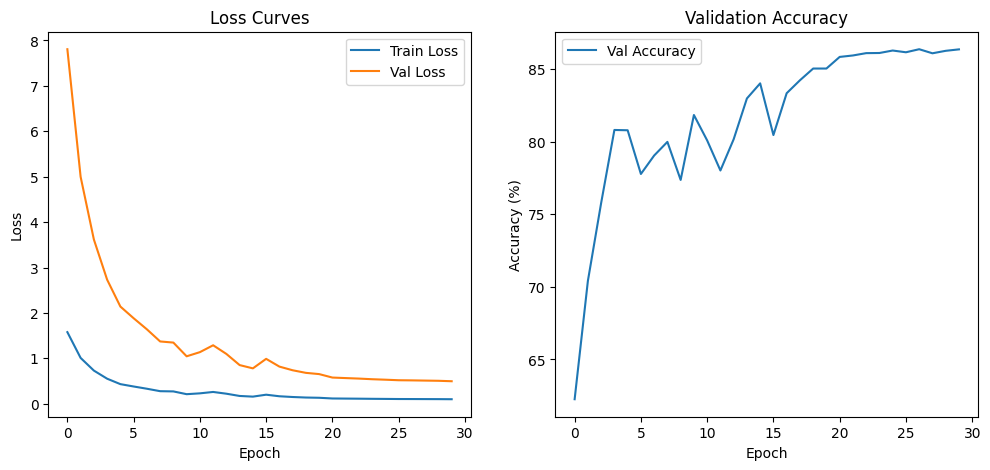

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

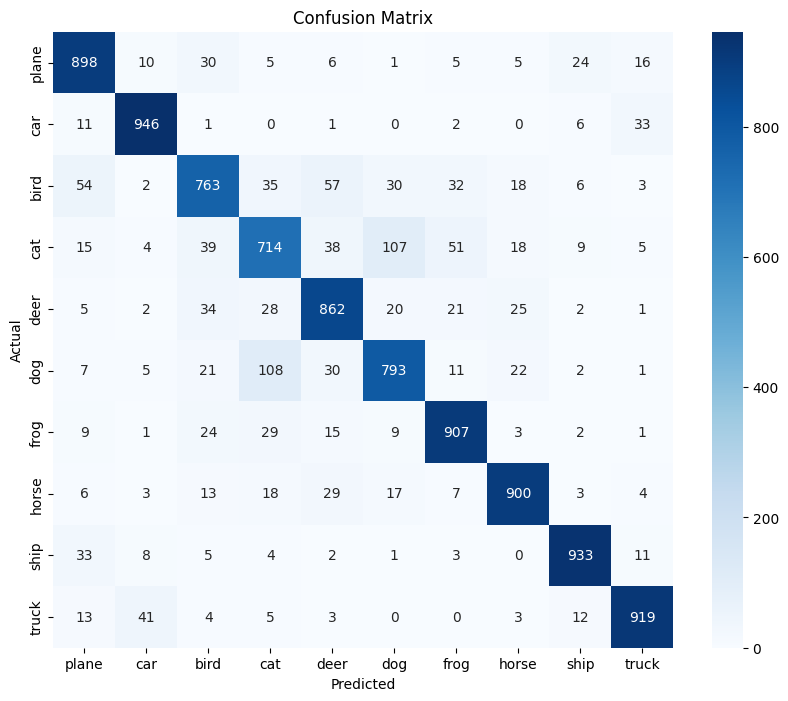

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Dropout p=0.5

In [ ]:
class ResNetWithDropout(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_p=0.0):
        super(ResNetWithDropout, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Dropout applied after Global Average Pooling
        self.dropout = nn.Dropout(p=dropout_p)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.linear(out)
        return out

def ResNet11_Dropout(p=0.5):
    return ResNetWithDropout(BasicBlock, [1, 1, 1, 1], dropout_p=p)

def ResNet18_Dropout(p=0.5):
    return ResNetWithDropout(BasicBlock, [2, 2, 2, 2], dropout_p=p)

##Resnet-11

In [ ]:
net = ResNet11_Dropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-11 (p=0.5)", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

# Export the model weights
model_name = "ResNet11_Dropout_05"
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Epoch: 0, Loss: 1.6977, Accuracy: 50.53%
Epoch: 1, Loss: 1.1068, Accuracy: 67.51%
Epoch: 2, Loss: 0.8910, Accuracy: 71.51%
Epoch: 3, Loss: 0.8045, Accuracy: 65.79%
Epoch: 4, Loss: 0.6240, Accuracy: 76.05%
Epoch: 5, Loss: 0.5215, Accuracy: 77.30%
Epoch: 6, Loss: 0.4505, Accuracy: 76.39%
Epoch: 7, Loss: 0.4187, Accuracy: 75.22%
Epoch: 8, Loss: 0.3182, Accuracy: 79.21%
Epoch: 9, Loss: 0.2754, Accuracy: 79.61%
Epoch: 10, Loss: 0.2558, Accuracy: 78.95%
Epoch: 11, Loss: 0.2405, Accuracy: 80.01%
Epoch: 12, Loss: 0.2191, Accuracy: 80.25%
Epoch: 13, Loss: 0.2243, Accuracy: 79.33%
Epoch: 14, Loss: 0.2167, Accuracy: 79.49%
Epoch: 15, Loss: 0.1942, Accuracy: 80.78%
Epoch: 16, Loss: 0.1788, Accuracy: 81.24%
Epoch: 17, Loss: 0.2154, Accuracy: 78.35%
Epoch: 18, Loss: 0.1707, Accuracy: 81.81%
Epoch: 19, Loss: 0.1654, Accuracy: 81.41%
Epoch: 20, Loss: 0.1405, Accuracy: 83.49%
Epoch: 21, Loss: 0.1371, Accuracy: 83.51%
Epoch: 22, Loss: 0.1275, Accuracy: 84.01%
Epoch: 23, Loss: 0.1229, Accuracy: 84.33%
Ep

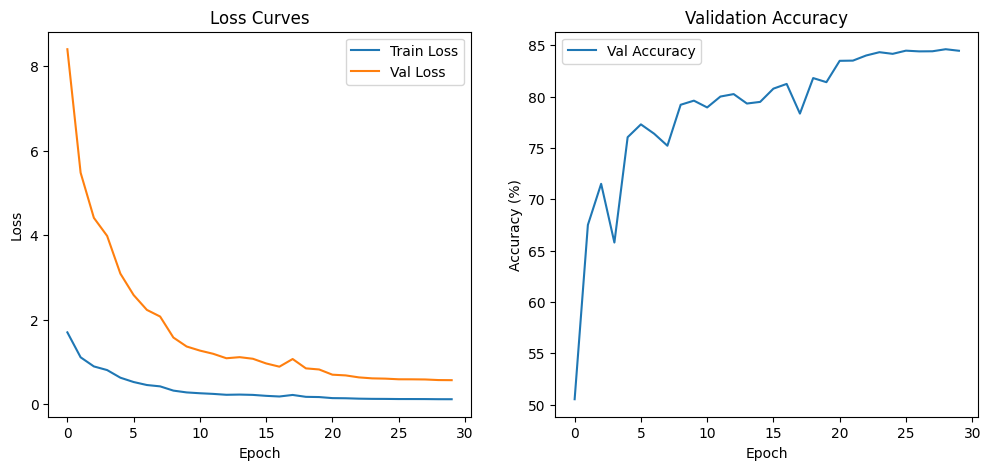

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

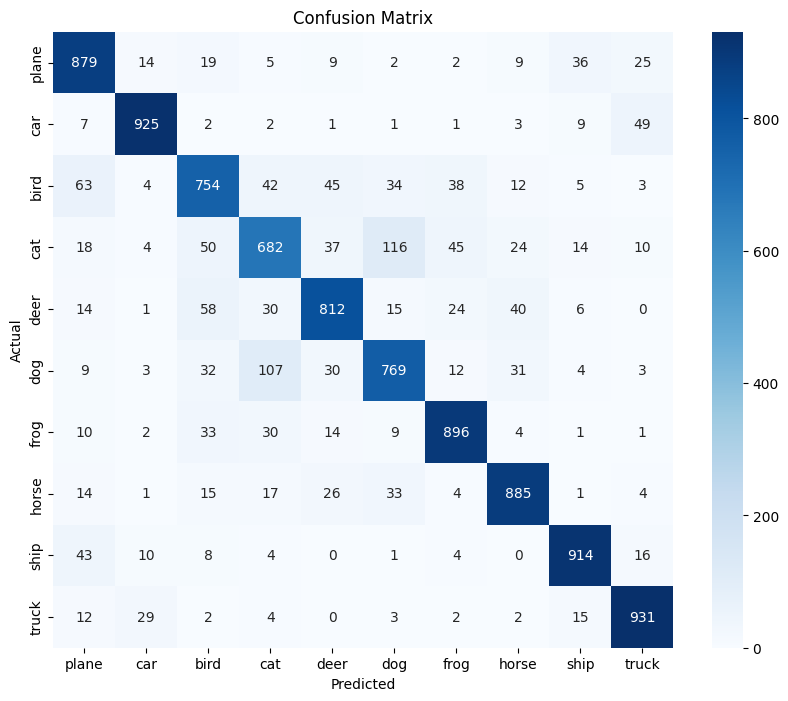

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##Resnet-18

In [ ]:
net = ResNet18_Dropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
train_loss_list, val_loss_list, val_accuracy_list = [], [], []
for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss_function = loss(outputs, labels)
        loss_function.backward()
        optimizer.step()
        running_loss += loss_function.item()

    correct, total = 0, 0
    net.eval()
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            running_loss += loss(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_accuracy_list.append(val_accuracy)
    print(f'Epoch: {epoch}, Loss: {train_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

all_model_results.append({"Model": "ResNet-18 (p=0.5)", "Train Loss": train_loss, "Val Accuracy": val_accuracy, "Val Loss": val_loss})

# Export the model weights
model_name = "ResNet18_Dropout_05"
torch.save(net.state_dict(), f"{model_name}.pth")
print(f"Model saved as {model_name}.pth")

Epoch: 0, Loss: 1.6596, Accuracy: 59.48%
Epoch: 1, Loss: 1.0262, Accuracy: 73.53%
Epoch: 2, Loss: 0.7613, Accuracy: 76.73%
Epoch: 3, Loss: 0.6026, Accuracy: 77.47%
Epoch: 4, Loss: 0.4724, Accuracy: 79.51%
Epoch: 5, Loss: 0.4172, Accuracy: 75.89%
Epoch: 6, Loss: 0.3182, Accuracy: 80.34%
Epoch: 7, Loss: 0.2948, Accuracy: 78.44%
Epoch: 8, Loss: 0.2543, Accuracy: 80.15%
Epoch: 9, Loss: 0.2342, Accuracy: 80.82%
Epoch: 10, Loss: 0.2248, Accuracy: 79.52%
Epoch: 11, Loss: 0.2013, Accuracy: 82.21%
Epoch: 12, Loss: 0.2190, Accuracy: 80.63%
Epoch: 13, Loss: 0.2030, Accuracy: 81.12%
Epoch: 14, Loss: 0.2001, Accuracy: 82.07%
Epoch: 15, Loss: 0.2191, Accuracy: 79.88%
Epoch: 16, Loss: 0.1876, Accuracy: 81.27%
Epoch: 17, Loss: 0.1816, Accuracy: 81.73%
Epoch: 18, Loss: 0.1896, Accuracy: 81.19%
Epoch: 19, Loss: 0.1630, Accuracy: 82.88%
Epoch: 20, Loss: 0.1604, Accuracy: 83.04%
Epoch: 21, Loss: 0.1496, Accuracy: 83.45%
Epoch: 22, Loss: 0.1483, Accuracy: 83.63%
Epoch: 23, Loss: 0.1515, Accuracy: 83.55%
Ep

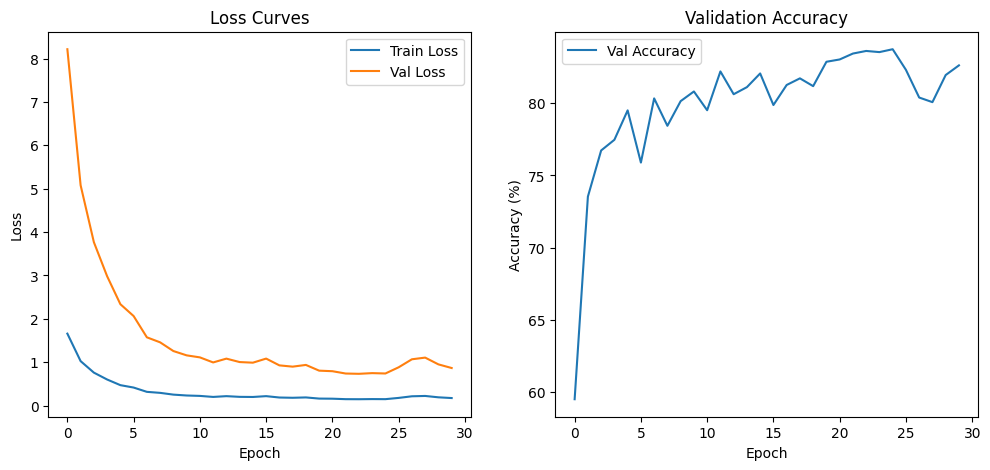

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracy_list, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

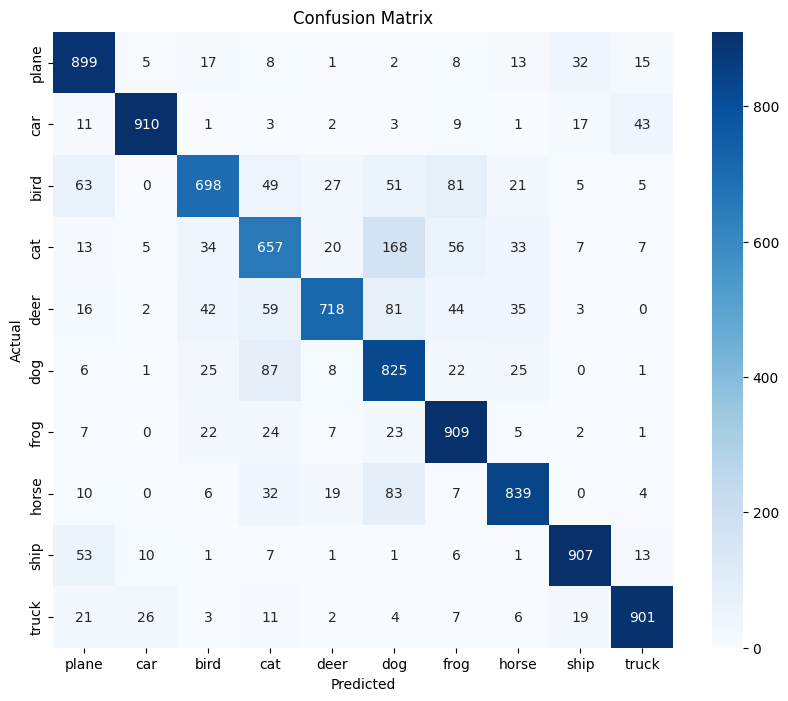

In [ ]:
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd
if 'all_model_results' in locals() and all_model_results:
    df_summary = pd.DataFrame(all_model_results)
    cols = ['Model', 'Train Loss', 'Val Accuracy', 'Val Loss']
    df_summary = df_summary[[c for c in cols if c in df_summary.columns]]
    print("Final Comparative Summary Table:")
    display(df_summary.round(4))

    # Export to txt
    with open('model_comparison_results.txt', 'w') as f:
        f.write(df_summary.to_string(index=False))
    print("\nSummary exported to model_comparison_results.txt")
else:
    print("Results list 'all_model_results' is empty or not initialized.")

Final Comparative Summary Table:


,Model,Train Loss,Val Accuracy,Val Loss
0,ResNet-11 Baseline,0.1180,83.62,0.5843
1,ResNet-18 Baseline,0.1075,85.24,0.5322
2,ResNet-11 (p=0.3),0.1150,84.30,0.5690
3,ResNet-18 (p=0.3),0.1003,86.35,0.4964
4,ResNet-11 (p=0.5),0.1142,84.47,0.5654
5,ResNet-18 (p=0.5),0.1752,82.63,0.8673



Summary exported to model_comparison_results.txt
